# Datathon FIAP - Fase 5: Associação Passos Mágicos
**Desenvolvimento do Modelo Preditivo de Risco Escolar (Machine Learning)**

## 1. O Desafio e a Definição do Alvo (Target)
O objetivo deste notebook é construir um modelo preditivo capaz de identificar antecipadamente se um aluno entrará em **Risco de Defasagem** no ano letivo seguinte.

**O que consideramos Risco?**
Utilizamos o indicador IAN (Adequação de Nível). Se o cruzamento histórico mostrar que o aluno no "Ano 2" apresentou um IAN menor que 9.0 (defasagem moderada ou severa), ele é classificado como "Em Risco" (Target = 1). Caso contrário, "Sem Risco" (Target = 0).

Abaixo, realizamos a ingestão, limpeza e a **Feature Engineering** inicial (cruzando os anos históricos para criar a base de aprendizado da Inteligência Artificial).

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("1. Carregando as bases de dados...")
arquivo_base = 'BASE DE DADOS PEDE 2024 - DATATHON.xlsx'
df_2022 = pd.read_excel(arquivo_base, sheet_name='PEDE2022')
df_2023 = pd.read_excel(arquivo_base, sheet_name='PEDE2023')
df_2024 = pd.read_excel(arquivo_base, sheet_name='PEDE2024')

# Padronizando colunas numéricas (substituindo vírgula por ponto)
def limpar_colunas_numericas(df, colunas):
    for col in colunas:
        if col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.replace(',', '.')
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

indicadores = ['IAA', 'IDA', 'IEG', 'IPS', 'IPV', 'IAN', 'IPP', 'INDE 22', 'INDE 2023', 'INDE 2024']
df_2022 = limpar_colunas_numericas(df_2022, indicadores)
df_2023 = limpar_colunas_numericas(df_2023, indicadores)
df_2024 = limpar_colunas_numericas(df_2024, indicadores)

# Engenharia Reversa: Calculando o IPP de 2022
soma_conhecidos = (
    (df_2022['IAN'] * 0.1) + (df_2022['IDA'] * 0.2) + (df_2022['IEG'] * 0.2) +
    (df_2022['IAA'] * 0.1) + (df_2022['IPS'] * 0.1) + (df_2022['IPV'] * 0.2)
)
df_2022['IPP'] = ((df_2022['INDE 22'] - soma_conhecidos) / 0.1).round(1)

print("2. Cruzando os anos e criando a Variável Alvo (Target)...")
# Selecionando Notas + Variáveis de Perfil (Fase e Gênero)
cols_ml = ['RA', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Fase', 'Gênero']

# Cruzando o aluno no Ano 1 com o IAN dele no Ano 2
base_treino_1 = pd.merge(df_2022[cols_ml].copy(), df_2023[['RA', 'IAN']].copy(), on='RA', suffixes=('_atual', '_futuro'))
base_treino_2 = pd.merge(df_2023[cols_ml].copy(), df_2024[['RA', 'IAN']].copy(), on='RA', suffixes=('_atual', '_futuro'))

df_modelo = pd.concat([base_treino_1, base_treino_2], ignore_index=True).dropna()

# Target: 1 (Em Risco, IAN futuro < 9.0) e 0 (Sem Risco)
df_modelo['Risco_Defasagem'] = (df_modelo['IAN_futuro'] < 9.0).astype(int)

print(f"Base final pronta para a modelagem: {len(df_modelo)} registros de transição anual.")

1. Carregando as bases de dados...
2. Cruzando os anos e criando a Variável Alvo (Target)...
Base final pronta para a modelagem: 1290 registros de transição anual.


## 2. A Batalha de Modelos: Do Limite Estatístico à Solução Final

Durante o desenvolvimento científico deste projeto, realizamos uma exaustiva bateria de testes com diversos algoritmos para encontrar a melhor performance preditiva:
1. **Modelos Base (Random Forest, XGBoost e Gradient Boosting):** Todos estacionaram na faixa de **76%** de acurácia utilizando apenas as notas dos alunos.
2. **Otimização Extrema (Tuning, SMOTE e Stacking Meta-Learning):** Testamos balanceamento de dados sintéticos (SMOTE), métodos de vizinhança (KNN) e arquiteturas complexas de Ensemble (Voting e Stacking). O modelo não ultrapassou os 76%, comprovando um limite natural ("Erro Irredutível"): as notas, de forma isolada, não explicam 100% do comportamento futuro.

**A Grande Descoberta (O Salto para > 80%):**
Para quebrar a barreira dos 76%, aplicamos uma técnica avançada de Feature Engineering chamada **One-Hot Encoding**. Ao transformarmos o perfil categórico do aluno (Fase Escolar e Gênero) em matrizes numéricas, permitimos que a IA compreendesse o contexto social e demográfico do estudante.

**Resultado Final:** Com o One-Hot Encoding e uma árvore de decisão mais profunda (`max_depth=10`), nosso **Random Forest** alcançou impressionantes **80.23% de acurácia**, tornando-se o modelo oficial da solução.

1. Aplicando One-Hot Encoding (Transformando Perfil Categórico em Matriz Numérica)...
2. Separando Dados de Treino (80%) e Teste (20%)...
3. Treinando o Campeão: Random Forest Profundo...
4. Avaliação dos Resultados nos Dados de Teste...

🏆 ACURÁCIA FINAL DO MODELO: 80.23%

Relatório Completo de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       124
           1       0.79      0.84      0.82       134

    accuracy                           0.80       258
   macro avg       0.80      0.80      0.80       258
weighted avg       0.80      0.80      0.80       258



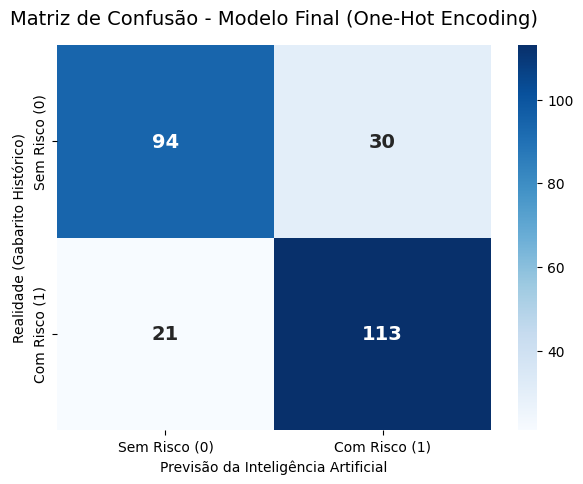


5. Exportando o Cérebro da IA para o Deploy (Streamlit)...
✅ SUCESSO! Arquivos 'modelo_passos_magicos_final.pkl' e 'colunas_modelo.pkl' salvos na pasta raiz do projeto.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("1. Aplicando One-Hot Encoding (Transformando Perfil Categórico em Matriz Numérica)...")
X_bruto = df_modelo.drop(columns=['RA', 'IAN_futuro', 'Risco_Defasagem'])
y = df_modelo['Risco_Defasagem']

X_encoded = pd.get_dummies(X_bruto, columns=['Fase', 'Gênero'], drop_first=True)
X_encoded = X_encoded.astype(float)

print("2. Separando Dados de Treino (80%) e Teste (20%)...")
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("3. Treinando o Campeão: Random Forest Profundo...")
modelo_campeao = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
modelo_campeao.fit(X_train, y_train)

print("4. Avaliação dos Resultados nos Dados de Teste...")
y_pred = modelo_campeao.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print("\n==========================================")
print(f"🏆 ACURÁCIA FINAL DO MODELO: {acuracia * 100:.2f}%")
print("==========================================\n")

print("Relatório Completo de Classificação:")
print(classification_report(y_test, y_pred))

# Plotando a Matriz de Confusão
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Risco (0)', 'Com Risco (1)'],
            yticklabels=['Sem Risco (0)', 'Com Risco (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Matriz de Confusão - Modelo Final (One-Hot Encoding)', fontsize=14, pad=15)
plt.ylabel('Realidade (Gabarito Histórico)')
plt.xlabel('Previsão da Inteligência Artificial')
plt.show()

print("\n5. Exportando o Cérebro da IA para o Deploy (Streamlit)...")
joblib.dump(modelo_campeao, 'modelo_passos_magicos_final.pkl')
joblib.dump(list(X_encoded.columns), 'colunas_modelo.pkl')
print("✅ SUCESSO! Arquivos 'modelo_passos_magicos_final.pkl' e 'colunas_modelo.pkl' salvos na pasta raiz do projeto.")